In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
lambda_1, lambda_2 = 2.7, 0.9
nu_1, nu_2 = 3, 1
alpha_1, alpha_2 = 2, 0.2
M = 1
T = 28
sigma = 1.0
dt = 0.001
t_steps = np.arange(0, T + dt, dt)

In [18]:
def h1(t):
    return 5 if t < 14 else 0

def h2(t):
    return 10 if t < 7 else 0

def P(b1, b2):
    return 3 if 1 <= (b1 + b2) <= 2 else 0

In [19]:
# ODE system for db1/dt and db2/dt
def odes(t, b1, b2, h_func):
    sigma_1 = sigma * alpha_1 * h_func(t)
    sigma_2 = sigma * alpha_2 * h_func(t)
    db1_dt = lambda_1 * b1 - nu_1 * b1**2 / (1 + b1**2) - sigma_1 * b1 - M * b1 / (1 + sigma_1)
    db2_dt = lambda_2 * b2 - nu_2 * b2**2 / (1 + b2**2) - sigma_2 * b2 + M * b2 / (1 + sigma_1)
    return db1_dt, db2_dt

In [20]:
def RK2(b1_0, b2_0, h_func):
    b1, b2 = b1_0, b2_0
    b1_values, b2_values = [b1], [b2]
    p_values = [P(b1, b2)]

    for t in t_steps[:-1]:
        k1_b1, k1_b2 = odes(t, b1, b2, h_func)
        k2_b1, k2_b2 = odes(t + dt / 2, b1 + k1_b1 * dt / 2, b2 + k1_b2 * dt / 2, h_func)

        b1 += k2_b1 * dt
        b2 += k2_b2 * dt

        b1_values.append(b1)
        b2_values.append(b2)
        p_values.append(P(b1, b2))  # Update patient population

    return np.array(b1_values), np.array(b2_values), np.array(p_values)

In [21]:
def compute_q2(b2_values, p_values):
    return np.trapz(b2_values * p_values, t_steps)

In [22]:
# Initial condition
b1_0, b2_0 = 1.0, 1.0

b1_1, b2_1, p1 = RK2(b1_0, b2_0, h1)
q2_1 = compute_q2(b2_1, p1)

b1_2, b2_2, p2 = RK2(b1_0, b2_0, h2)
q2_2 = compute_q2(b2_2, p2)

print(f"Q2(T) for Strategy 1: {q2_1:.4f}")
print(f"Q2(T) for Strategy 2: {q2_2:.4f}")

Q2(T) for Strategy 1: 2.7958
Q2(T) for Strategy 2: 2.3691


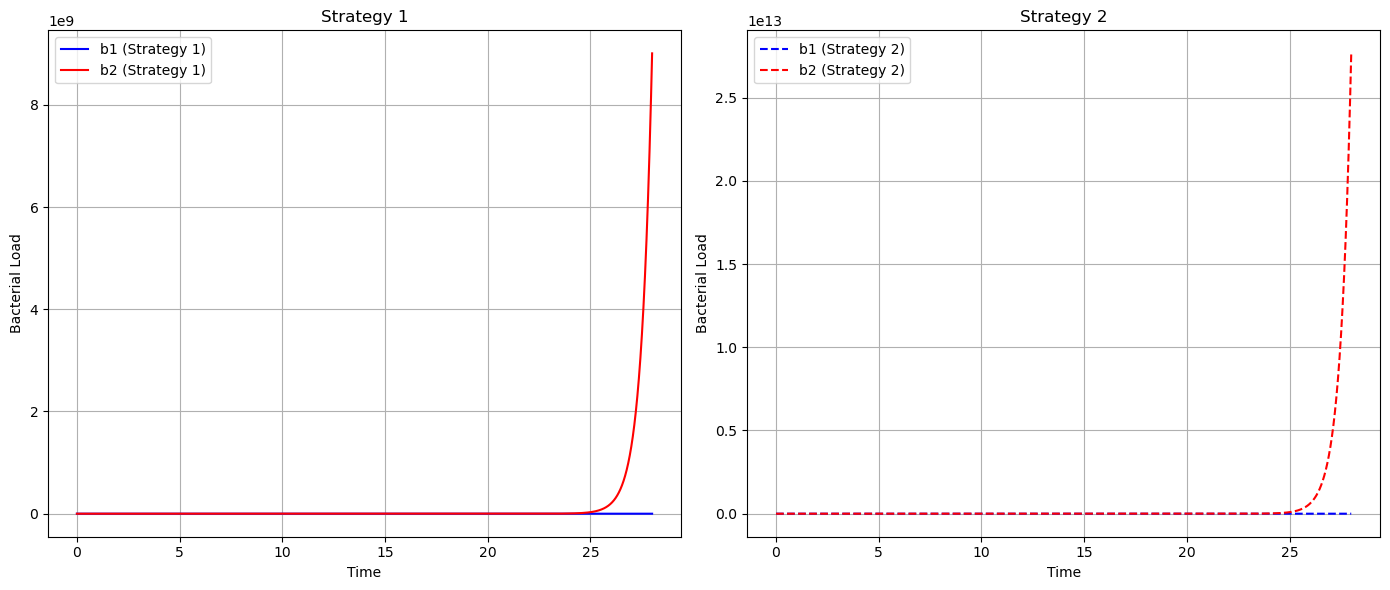

In [23]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(t_steps, b1_1, label="b1 (Strategy 1)", color="blue")
plt.plot(t_steps, b2_1, label="b2 (Strategy 1)", color="red")
plt.xlabel("Time")
plt.ylabel("Bacterial Load")
plt.title("Strategy 1")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(t_steps, b1_2, label="b1 (Strategy 2)", color="blue", linestyle="--")
plt.plot(t_steps, b2_2, label="b2 (Strategy 2)", color="red", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Bacterial Load")
plt.title("Strategy 2")
plt.legend()
plt.grid()

plt.tight_layout()